<center>
<img src="https://laelgelcpublic.s3.sa-east-1.amazonaws.com/lael_50_years_narrow_white.png.no_years.400px_96dpi.png" width="300" alt="LAEL 50 years logo">
<h3>APPLIED LINGUISTICS GRADUATE PROGRAMME (LAEL)</h3>
</center>
<hr>

# Corpus Linguistics - Study 1 - Phase 3 - Tatiana

This document aims to organise the tweet verbal and visual subcorpora data for Canonical Correlation Analysis (CCA).

## Tweet Verbal Subcorpus

Define the project name.

In [1]:
PROJECT = "cl_st1_ph2_tatiana"

In [2]:
from pathlib import Path

SCORES_FILE = Path(f"../{PROJECT}/docs/tati_oms/tati_scores_only.tsv")

### Load factor scores

In [3]:
import pandas as pd

scores_verbal_df = pd.read_csv(SCORES_FILE, sep="\t")
scores_verbal_df = scores_verbal_df.rename(columns={"file": "file_id"})

scores_verbal_df

,file_id,fac1,fac2,fac3,fac4,fac5,fac6
0,tweet_00000002,-2,1,0,0,0,0
1,tweet_00000003,-3,2,0,0,0,1
2,tweet_00000004,0,0,-1,0,0,0
3,tweet_00000005,0,0,-1,0,0,0
4,tweet_00000006,1,1,0,-1,0,0
...,...,...,...,...,...,...,...
126863,tweet_00163249,0,0,0,0,0,0
126864,tweet_00163250,1,0,0,0,0,0
126865,tweet_00163251,-1,3,1,-1,0,0
126866,tweet_00163252,0,0,0,0,0,3


### Prepare verbal factor-score columns for CCA

Rename the verbal factor-score columns from `fac<n>` to `ver<n>` and keep only the file identifiers, decade metadata, and renamed verbal score columns needed for Canonical Correlation Analysis.

In [4]:
import re

verbal_factor_cols = [col for col in scores_verbal_df.columns if re.fullmatch(r"fac\d+", col)]
verbal_factor_cols = sorted(verbal_factor_cols, key=lambda col: int(col.replace("fac", "")))

verbal_rename_map = {
    col: col.replace("fac", "ver")
    for col in verbal_factor_cols
}

scores_verbal_df = scores_verbal_df.rename(columns=verbal_rename_map)

verbal_cols = [verbal_rename_map[col] for col in verbal_factor_cols]

scores_verbal_df = scores_verbal_df[
    ["file_id"] + verbal_cols
    ]

scores_verbal_df

,file_id,ver1,ver2,ver3,ver4,ver5,ver6
0,tweet_00000002,-2,1,0,0,0,0
1,tweet_00000003,-3,2,0,0,0,1
2,tweet_00000004,0,0,-1,0,0,0
3,tweet_00000005,0,0,-1,0,0,0
4,tweet_00000006,1,1,0,-1,0,0
...,...,...,...,...,...,...,...
126863,tweet_00163249,0,0,0,0,0,0
126864,tweet_00163250,1,0,0,0,0,0
126865,tweet_00163251,-1,3,1,-1,0,0
126866,tweet_00163252,0,0,0,0,0,3


### Load tweets corpus

In [5]:
TWEETS_FILE = Path(f"../{PROJECT}/corpus/tweets.ndjson")

tweets_df = pd.read_json(TWEETS_FILE, lines=True)

tweets_df

,file,created_at,text_uniq,conversation_id,author_id,username,tweet_url,text,photo_uniq_id
0,saude202003_n_00001.json,2020-03-30 23:58:27,tweet_00000006,convo_1244774019859206145,id_173533635,unknown,unknown,"Lembrando q estamos atendendo somente on-line,...",saude202003_n_00001_00000001.jpg
1,saude202003_n_00001.json,2020-03-30 23:54:45,tweet_00000007,convo_1244774019859206145,id_173533635,unknown,unknown,"Não é muito, mas é a forma que encontramos par...",saude202003_n_00001_00000001.jpg
2,saude202003_n_00001.json,2020-03-30 23:50:57,tweet_00000022,convo_1244774142701981698,id_454396343,unknown,unknown,"Segundo levantamento da AFP (dados da OMS) 3,3...",saude202003_n_00001_00000002.jpg
3,saude202003_n_00002.json,2020-03-30 23:27:18,tweet_00000051,convo_1244693362361487364,id_191068627,sf79,https://twitter.com/sf79/status/12446933623614...,@cmelo @Francischini_ @jairbolsonaro A OMS nun...,saude202003_n_00002_00000001.jpg
4,saude202003_n_00002.json,2020-03-30 23:26:49,tweet_00000054,convo_1244768070524166145,id_199501770,unknown,unknown,OMS diz que não há transmissão aérea de Covid-...,saude202003_n_00002_00000002.jpg
...,...,...,...,...,...,...,...,...,...
15782,saude202303_n_00207.json,2023-03-06 23:52:37,tweet_00163212,convo_1632891969536966663,id_1485793803495641090,VascoN95,https://twitter.com/VascoN95/status/1632891969...,Neste guia atualizado em fevereiro de 2023 sob...,saude202303_n_00207_00000001.jpg
15783,saude202303_n_00207.json,2023-03-07 09:36:34,tweet_00163219,convo_1633038922753122305,id_1501277332119511048,chris_banida,https://twitter.com/chris_banida/status/163303...,Em breve esse venen☠️ virá para as crianças. h...,saude202303_n_00207_00000002.jpg
15784,saude202303_n_00207.json,2023-03-07 08:45:13,tweet_00163225,convo_1633026002245890049,id_2370633043,unknown,unknown,Aumenta a preocupação da OMS com a gripe aviár...,saude202303_n_00207_00000003.jpg
15785,saude202303_n_00207.json,2023-03-07 02:30:35,tweet_00163233,convo_1632931722000990210,id_1602447377771773953,anamanerolemos,https://twitter.com/anamanerolemos/status/1632...,A OMS muda seu plano de pandemia (que não menc...,saude202303_n_00207_00000004.png


### Add image IDs to verbal factor scores

In [6]:
image_id_map = tweets_df.set_index("text_uniq")["photo_uniq_id"]

scores_verbal_df.insert(
    loc=scores_verbal_df.columns.get_loc("file_id") + 1,
    column="image_id",
    value=scores_verbal_df["file_id"].map(image_id_map),
)

scores_verbal_df

,file_id,image_id,ver1,ver2,ver3,ver4,ver5,ver6
0,tweet_00000002,NaN,-2,1,0,0,0,0
1,tweet_00000003,NaN,-3,2,0,0,0,1
2,tweet_00000004,NaN,0,0,-1,0,0,0
3,tweet_00000005,NaN,0,0,-1,0,0,0
4,tweet_00000006,saude202003_n_00001_00000001.jpg,1,1,0,-1,0,0
...,...,...,...,...,...,...,...,...
126863,tweet_00163249,NaN,0,0,0,0,0,0
126864,tweet_00163250,saude202303_n_00207_00000005.jpg,1,0,0,0,0,0
126865,tweet_00163251,NaN,-1,3,1,-1,0,0
126866,tweet_00163252,NaN,0,0,0,0,0,3


## Tweet Visual Subcorpus

Define the project name.

In [7]:
PROJECT = "cl_st1_ph2_tatiana"

In [8]:
from pathlib import Path

SCORES_FILE = Path(f"../{PROJECT}/sas/output_{PROJECT}/{PROJECT}_scores_only.tsv")
FILE_IDS_PATH = Path(f"../{PROJECT}/file_ids.txt")

### Load factor scores

In [9]:
import pandas as pd

scores_visual_df = pd.read_csv(SCORES_FILE, sep="\t")
scores_visual_df = scores_visual_df.rename(columns={"filename": "text_id"})

scores_visual_df

,text_id,fac1,fac2,fac3,fac4,fac5,fac6,fac7
0,t000001,0,0,0,0,0,0,-2
1,t000002,1,0,0,1,0,0,-2
2,t000003,6,0,0,0,0,0,-6
3,t000004,1,0,0,1,0,0,-3
4,t000005,19,-1,0,1,0,1,0
...,...,...,...,...,...,...,...,...
11844,t011865,0,0,0,0,0,0,-4
11845,t011866,3,0,0,0,0,0,-4
11846,t011867,0,0,0,0,0,-5,0
11847,t011868,0,8,0,4,0,0,19


### Load file ID mapping

In [10]:
file_ids_visual_df = pd.read_csv(
    FILE_IDS_PATH,
    sep=" ",
    names=["text_id", "filename"],
)

file_ids_visual_df.head()

,text_id,filename
0,t000001,saude202003_n_00001_00000001.txt
1,t000002,saude202003_n_00001_00000002.txt
2,t000003,saude202003_n_00002_00000001.txt
3,t000004,saude202003_n_00002_00000002.txt
4,t000005,saude202003_n_00002_00000003.txt


### Merge factor scores with file ID mapping

In [11]:
scores_file_ids_visual_df = scores_visual_df.merge(file_ids_visual_df, on="text_id", how="left")
scores_file_ids_visual_df = scores_file_ids_visual_df[
    ["text_id", "filename"]
    + [col for col in scores_file_ids_visual_df.columns if col not in ["text_id", "filename"]]
    ]

scores_file_ids_visual_df

,text_id,filename,fac1,fac2,fac3,fac4,fac5,fac6,fac7
0,t000001,saude202003_n_00001_00000001.txt,0,0,0,0,0,0,-2
1,t000002,saude202003_n_00001_00000002.txt,1,0,0,1,0,0,-2
2,t000003,saude202003_n_00002_00000001.txt,6,0,0,0,0,0,-6
3,t000004,saude202003_n_00002_00000002.txt,1,0,0,1,0,0,-3
4,t000005,saude202003_n_00002_00000003.txt,19,-1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...
11844,t011865,saude202303_n_00207_00000001.txt,0,0,0,0,0,0,-4
11845,t011866,saude202303_n_00207_00000002.txt,3,0,0,0,0,0,-4
11846,t011867,saude202303_n_00207_00000003.txt,0,0,0,0,0,-5,0
11847,t011868,saude202303_n_00207_00000004.txt,0,8,0,4,0,0,19


### Prepare visual factor-score columns for CCA

Rename the visual factor-score columns from `fac<n>` to `vis<n>` and keep only the file identifiers, decade metadata, and renamed visual score columns needed for Canonical Correlation Analysis.

In [12]:
import re

verbal_factor_cols = [col for col in scores_file_ids_visual_df.columns if re.fullmatch(r"fac\d+", col)]
verbal_factor_cols = sorted(verbal_factor_cols, key=lambda col: int(col.replace("fac", "")))

verbal_rename_map = {
    col: col.replace("fac", "vis")
    for col in verbal_factor_cols
}

scores_file_ids_visual_df = scores_file_ids_visual_df.rename(columns=verbal_rename_map)

verbal_cols = [verbal_rename_map[col] for col in verbal_factor_cols]

scores_file_ids_visual_df = scores_file_ids_visual_df[
    ["text_id", "filename"] + verbal_cols
    ]

scores_file_ids_visual_df

,text_id,filename,vis1,vis2,vis3,vis4,vis5,vis6,vis7
0,t000001,saude202003_n_00001_00000001.txt,0,0,0,0,0,0,-2
1,t000002,saude202003_n_00001_00000002.txt,1,0,0,1,0,0,-2
2,t000003,saude202003_n_00002_00000001.txt,6,0,0,0,0,0,-6
3,t000004,saude202003_n_00002_00000002.txt,1,0,0,1,0,0,-3
4,t000005,saude202003_n_00002_00000003.txt,19,-1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...
11844,t011865,saude202303_n_00207_00000001.txt,0,0,0,0,0,0,-4
11845,t011866,saude202303_n_00207_00000002.txt,3,0,0,0,0,0,-4
11846,t011867,saude202303_n_00207_00000003.txt,0,0,0,0,0,-5,0
11847,t011868,saude202303_n_00207_00000004.txt,0,8,0,4,0,0,19


### Add verbal file IDs to visual scores

In [13]:
visual_to_verbal_file_id_map = (
    scores_verbal_df
    .dropna(subset=["image_id"])
    .assign(image_stem=lambda df: df["image_id"].map(lambda value: Path(value).stem))
    .drop_duplicates(subset="image_stem")
    .set_index("image_stem")["file_id"]
)

visual_filename_stems = scores_file_ids_visual_df["filename"].map(lambda value: Path(value).stem)

scores_file_ids_visual_df.insert(
    loc=scores_file_ids_visual_df.columns.get_loc("text_id") + 1,
    column="file_id",
    value=visual_filename_stems.map(visual_to_verbal_file_id_map),
)

scores_file_ids_visual_df

,text_id,file_id,filename,vis1,vis2,vis3,vis4,vis5,vis6,vis7
0,t000001,tweet_00000006,saude202003_n_00001_00000001.txt,0,0,0,0,0,0,-2
1,t000002,tweet_00000022,saude202003_n_00001_00000002.txt,1,0,0,1,0,0,-2
2,t000003,tweet_00000051,saude202003_n_00002_00000001.txt,6,0,0,0,0,0,-6
3,t000004,tweet_00000054,saude202003_n_00002_00000002.txt,1,0,0,1,0,0,-3
4,t000005,tweet_00000073,saude202003_n_00002_00000003.txt,19,-1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...
11844,t011865,tweet_00163212,saude202303_n_00207_00000001.txt,0,0,0,0,0,0,-4
11845,t011866,tweet_00163219,saude202303_n_00207_00000002.txt,3,0,0,0,0,0,-4
11846,t011867,tweet_00163225,saude202303_n_00207_00000003.txt,0,0,0,0,0,-5,0
11847,t011868,tweet_00163233,saude202303_n_00207_00000004.txt,0,8,0,4,0,0,19


## Identify misalignment between visual and verbal dimension score DataFrames

In [14]:
verbal_file_ids = set(scores_verbal_df["file_id"])
visual_file_ids = set(scores_file_ids_visual_df["file_id"])

file_id_diff = {
    "only_in_verbal": sorted(verbal_file_ids - visual_file_ids),
    "only_in_visual": sorted(visual_file_ids - verbal_file_ids),
    "n_only_in_verbal": len(verbal_file_ids - visual_file_ids),
    "n_only_in_visual": len(visual_file_ids - verbal_file_ids),
    "n_in_both": len(verbal_file_ids & visual_file_ids),
    "n_verbal": len(verbal_file_ids),
    "n_visual": len(visual_file_ids),
}

display(file_id_diff)

{'only_in_verbal': ['tweet_00000002',
  'tweet_00000003',
  'tweet_00000004',
  'tweet_00000005',
  'tweet_00000007',
  'tweet_00000008',
  'tweet_00000009',
  'tweet_00000010',
  'tweet_00000011',
  'tweet_00000015',
  'tweet_00000016',
  'tweet_00000017',
  'tweet_00000018',
  'tweet_00000019',
  'tweet_00000020',
  'tweet_00000021',
  'tweet_00000023',
  'tweet_00000024',
  'tweet_00000025',
  'tweet_00000026',
  'tweet_00000027',
  'tweet_00000030',
  'tweet_00000031',
  'tweet_00000032',
  'tweet_00000033',
  'tweet_00000034',
  'tweet_00000035',
  'tweet_00000037',
  'tweet_00000038',
  'tweet_00000039',
  'tweet_00000040',
  'tweet_00000041',
  'tweet_00000042',
  'tweet_00000043',
  'tweet_00000044',
  'tweet_00000045',
  'tweet_00000046',
  'tweet_00000047',
  'tweet_00000048',
  'tweet_00000049',
  'tweet_00000050',
  'tweet_00000052',
  'tweet_00000053',
  'tweet_00000055',
  'tweet_00000056',
  'tweet_00000057',
  'tweet_00000058',
  'tweet_00000059',
  'tweet_00000060',
  

## Merge verbal and visual scores for CCA

Create the CCA-ready dataset by inner-merging the verbal and visual score DataFrames on `file_id`, keeping only commercials present in both modalities.

In [15]:
cca_df = scores_verbal_df.merge(
    scores_file_ids_visual_df,
    on="file_id",
    how="inner",
)

cca_df

,file_id,image_id,ver1,ver2,ver3,ver4,ver5,ver6,text_id,filename,vis1,vis2,vis3,vis4,vis5,vis6,vis7
0,tweet_00000006,saude202003_n_00001_00000001.jpg,1,1,0,-1,0,0,t000001,saude202003_n_00001_00000001.txt,0,0,0,0,0,0,-2
1,tweet_00000022,saude202003_n_00001_00000002.jpg,-1,3,0,0,0,0,t000002,saude202003_n_00001_00000002.txt,1,0,0,1,0,0,-2
2,tweet_00000051,saude202003_n_00002_00000001.jpg,-1,2,0,-1,-1,0,t000003,saude202003_n_00002_00000001.txt,6,0,0,0,0,0,-6
3,tweet_00000054,saude202003_n_00002_00000002.jpg,1,1,-1,0,0,0,t000004,saude202003_n_00002_00000002.txt,1,0,0,1,0,0,-3
4,tweet_00000073,saude202003_n_00002_00000003.jpg,1,2,0,-1,0,0,t000005,saude202003_n_00002_00000003.txt,19,-1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11844,tweet_00163212,saude202303_n_00207_00000001.jpg,0,1,0,1,0,2,t011865,saude202303_n_00207_00000001.txt,0,0,0,0,0,0,-4
11845,tweet_00163219,saude202303_n_00207_00000002.jpg,0,0,0,0,0,1,t011866,saude202303_n_00207_00000002.txt,3,0,0,0,0,0,-4
11846,tweet_00163225,saude202303_n_00207_00000003.jpg,0,2,0,0,0,0,t011867,saude202303_n_00207_00000003.txt,0,0,0,0,0,-5,0
11847,tweet_00163233,saude202303_n_00207_00000004.png,0,3,0,-1,0,0,t011868,saude202303_n_00207_00000004.txt,0,8,0,4,0,0,19


In [16]:
cca_df = cca_df.drop(
    columns=[
        "text_id",
        "filename",
    ]
)

cca_df

,file_id,image_id,ver1,ver2,ver3,ver4,ver5,ver6,vis1,vis2,vis3,vis4,vis5,vis6,vis7
0,tweet_00000006,saude202003_n_00001_00000001.jpg,1,1,0,-1,0,0,0,0,0,0,0,0,-2
1,tweet_00000022,saude202003_n_00001_00000002.jpg,-1,3,0,0,0,0,1,0,0,1,0,0,-2
2,tweet_00000051,saude202003_n_00002_00000001.jpg,-1,2,0,-1,-1,0,6,0,0,0,0,0,-6
3,tweet_00000054,saude202003_n_00002_00000002.jpg,1,1,-1,0,0,0,1,0,0,1,0,0,-3
4,tweet_00000073,saude202003_n_00002_00000003.jpg,1,2,0,-1,0,0,19,-1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11844,tweet_00163212,saude202303_n_00207_00000001.jpg,0,1,0,1,0,2,0,0,0,0,0,0,-4
11845,tweet_00163219,saude202303_n_00207_00000002.jpg,0,0,0,0,0,1,3,0,0,0,0,0,-4
11846,tweet_00163225,saude202303_n_00207_00000003.jpg,0,2,0,0,0,0,0,0,0,0,0,-5,0
11847,tweet_00163233,saude202303_n_00207_00000004.png,0,3,0,-1,0,0,0,8,0,4,0,0,19


### Save the verbal and visual scores as NDJSON, Excel, and TSV

In [17]:
cca_df.to_json(
    "../cl_st1_ph2_tatiana/corpus/tweets_cca.ndjson",
    orient="records",
    lines=True,
    force_ascii=False
)

cca_df.to_excel(
    "../cl_st1_ph2_tatiana/corpus/tweets_cca.xlsx",
    index=False,
    engine="openpyxl"
)

cca_df.to_csv(
    "../cl_st1_ph2_tatiana/corpus/tweets_cca.tsv",
    sep="\t",
    index=False
)

## CCA Results Verification

### Import results

#### Import `Correlations Between the VAR Variables and Their Canonical Variables`

In [18]:
import pandas as pd

cca_var_df = pd.read_json("cca_var.json")

cca_var_df

,Variable,V1,V2,V3,V4,V5,V6
0,ver1,0.6448,0.6703,-0.2323,-0.1564,-0.2208,0.0883
1,ver2,-0.6973,0.5609,0.2834,0.1695,0.1177,0.2763
2,ver3,0.0639,0.0318,0.3252,-0.7071,0.2458,-0.5734
3,ver4,0.5282,-0.0442,0.7078,0.4052,0.1767,-0.1503
4,ver5,0.2040,-0.3548,0.3762,-0.4722,-0.2003,0.6541
5,ver6,0.2125,-0.0964,-0.3082,0.0198,0.8775,0.2831


#### Import `Correlations Between the WITH Variables and Their Canonical Variables`

In [19]:
import pandas as pd

cca_with_df = pd.read_json("cca_with.json")

cca_with_df

,Variable,W1,W2,W3,W4,W5,W6
0,vis1,-0.1197,0.0058,0.0187,-0.0302,-0.4022,0.2958
1,vis2,-0.5044,0.3845,0.3897,0.3561,0.5320,0.1697
2,vis3,-0.2586,0.1264,-0.2065,0.5251,-0.3333,-0.6948
3,vis4,0.8716,0.2677,-0.1191,0.2474,0.2562,-0.0674
4,vis5,0.1225,0.1569,0.3410,0.3812,-0.6278,0.3678
5,vis6,-0.2199,0.4446,-0.7788,0.1603,-0.1765,0.2577
6,vis7,-0.2510,0.8105,0.3611,-0.3328,0.0027,-0.0798


### Inspect Canonical Structure Loadings for the most statistical significant CCA Dimensions

Statistically significant CCA dimensions are the ones whose `p` is lower than `α = .05`.

This cell extracts the strongest canonical structure loadings for a configurable number of canonical dimensions. For each dimension, the verbal structure column (`V<n>`) is aligned with the corresponding visual structure column (`W<n>`). Variables are retained when their absolute loading is at least `.30`, while the original sign of the loading is preserved. The resulting dictionaries show which verbal and visual dimensions are most strongly associated with each canonical variate, sorted from highest to lowest loading.

These canonical structure loadings are used as the main basis for substantive interpretation because they show how strongly each original verbal or visual dimension correlates with its corresponding canonical variate.

In [20]:
EXTRACT_CANONICAL_DIMENSIONS = 5

In [21]:
import re

def get_sorted_loadings(df, score_col, cutoff=0.3):
    loadings = {
        row["Variable"]: row[score_col]
        for _, row in df.iterrows()
        if abs(row[score_col]) >= cutoff
    }

    return dict(sorted(loadings.items(), key=lambda item: item[1], reverse=True))


def get_dimension_numbers(df, prefix):
    """Return sorted canonical-dimension numbers available for a column prefix."""
    dimension_numbers = []

    for col in df.columns:
        match = re.fullmatch(rf"{prefix}(\d+)", col)

        if match:
            dimension_numbers.append(int(match.group(1)))

    return sorted(dimension_numbers)


available_var_dimensions = get_dimension_numbers(cca_var_df, "V")
available_with_dimensions = get_dimension_numbers(cca_with_df, "W")

available_paired_dimensions = sorted(
    set(available_var_dimensions) & set(available_with_dimensions)
)

if not available_paired_dimensions:
    raise ValueError("No paired VAR/WITH canonical dimensions were found.")

if EXTRACT_CANONICAL_DIMENSIONS > len(available_paired_dimensions):
    raise ValueError(
        f"EXTRACT_CANONICAL_DIMENSIONS={EXTRACT_CANONICAL_DIMENSIONS}, "
        f"but only {len(available_paired_dimensions)} paired canonical dimensions "
        f"are available: {available_paired_dimensions}."
    )

selected_dimensions = available_paired_dimensions[:EXTRACT_CANONICAL_DIMENSIONS]

cca_dimension_loadings = {}

for i in selected_dimensions:
    v_col = f"V{i}"
    w_col = f"W{i}"

    cca_dimension_loadings[f"canonical_dimension_{i}"] = {
        "VAR": get_sorted_loadings(cca_var_df, v_col),
        "WITH": get_sorted_loadings(cca_with_df, w_col),
    }

cca_dimension_loadings

{'canonical_dimension_1': {'VAR': {'ver1': 0.6448,
   'ver4': 0.5282,
   'ver2': -0.6973},
  'WITH': {'vis4': 0.8716, 'vis2': -0.5044000000000001}},
 'canonical_dimension_2': {'VAR': {'ver1': 0.6703,
   'ver2': 0.5609000000000001,
   'ver5': -0.3548},
  'WITH': {'vis7': 0.8105, 'vis6': 0.4446, 'vis2': 0.3845}},
 'canonical_dimension_3': {'VAR': {'ver4': 0.7078,
   'ver5': 0.37620000000000003,
   'ver3': 0.3252,
   'ver6': -0.30820000000000003},
  'WITH': {'vis2': 0.38970000000000005,
   'vis7': 0.36110000000000003,
   'vis5': 0.341,
   'vis6': -0.7788}},
 'canonical_dimension_4': {'VAR': {'ver4': 0.4052,
   'ver5': -0.4722,
   'ver3': -0.7071000000000001},
  'WITH': {'vis3': 0.5251,
   'vis5': 0.38120000000000004,
   'vis2': 0.3561,
   'vis7': -0.33280000000000004}},
 'canonical_dimension_5': {'VAR': {'ver6': 0.8775000000000001},
  'WITH': {'vis2': 0.532,
   'vis3': -0.33330000000000004,
   'vis1': -0.4022,
   'vis5': -0.6278}}}

### Visualise the canonical dimension loadings

#### Canonical dimension loadings

In [22]:
import pandas as pd

rows = []

for dimension_name, modalities in cca_dimension_loadings.items():
    dimension_number = int(dimension_name.replace("canonical_dimension_", ""))

    for modality, variables in modalities.items():
        for variable, loading in variables.items():
            rows.append(
                {
                    "canonical_dimension": dimension_number,
                    "modality": modality,
                    "variable": variable,
                    "loading": loading,
                }
            )

cca_dimension_loadings_df = pd.DataFrame(rows)

if cca_dimension_loadings_df.empty:
    raise ValueError("cca_dimension_loadings_df is empty. Check cca_dimension_loadings input.")

cca_dimension_loadings_df = cca_dimension_loadings_df.sort_values(
    ["canonical_dimension", "modality", "loading"],
    ascending=[True, True, False],
).reset_index(drop=True)

cca_dimension_loadings_df

,canonical_dimension,modality,variable,loading
0,1,VAR,ver1,0.6448
1,1,VAR,ver4,0.5282
2,1,VAR,ver2,-0.6973
3,1,WITH,vis4,0.8716
4,1,WITH,vis2,-0.5044
5,2,VAR,ver1,0.6703
6,2,VAR,ver2,0.5609
7,2,VAR,ver5,-0.3548
8,2,WITH,vis7,0.8105
9,2,WITH,vis6,0.4446


##### Save the canonical dimension loadings as NDJSON, Excel, and TSV

In [23]:
cca_dimension_loadings_df.to_json(
    "../cl_st1_ph2_tatiana/corpus/tweets_cca_dimension_loadings.ndjson",
    orient="records",
    lines=True,
    force_ascii=False
)

cca_dimension_loadings_df.to_excel(
    "../cl_st1_ph2_tatiana/corpus/tweets_cca_dimension_loadings.xlsx",
    index=False,
    engine="openpyxl"
)

cca_dimension_loadings_df.to_csv(
    "../cl_st1_ph2_tatiana/corpus/tweets_cca_dimension_loadings.tsv",
    sep="\t",
    index=False
)

#### Retrieve the CCA dimension loadings DataFrame from the corresponding NDJSON file

In [24]:
import pandas as pd

cca_dimension_loadings_df = pd.read_json(
    "../cl_st1_ph2_tatiana/corpus/tweets_cca_dimension_loadings.ndjson",
    lines=True,
)

#### Combined table with paired `VAR` and `WITH` columns

In [26]:
from pathlib import Path

output_dir = Path("../cl_st1_ph2_tatiana/corpus/tables/cca_dimension_loadings")
output_dir.mkdir(parents=True, exist_ok=True)

saved_latex_paths = []

for dimension in sorted(cca_dimension_loadings_df["canonical_dimension"].unique()):
    display_df = (
        cca_dimension_loadings_df[
            cca_dimension_loadings_df["canonical_dimension"].eq(dimension)
        ][["modality", "variable", "loading"]]
        .sort_values(
            ["modality", "loading"],
            ascending=[True, False],
        )
        .reset_index(drop=True)
    )

    dimension_number = str(dimension)

    print(f"Canonical dimension {dimension_number}")
    display(display_df)

    latex_table = display_df.to_latex(
        index=False,
        float_format="%.4f",
        caption=f"Canonical dimension {dimension_number} structure loadings",
        label=f"tab:cca_dimension_{dimension_number}_loadings",
        column_format="llr",
        escape=True,
    )

    output_path = output_dir / f"cca_dimension_{dimension_number}_loadings.tex"
    output_path.write_text(latex_table, encoding="utf-8")

    saved_latex_paths.append(output_path)

saved_latex_paths

Canonical dimension 1


,modality,variable,loading
0,VAR,ver1,0.6448
1,VAR,ver4,0.5282
2,VAR,ver2,-0.6973
3,WITH,vis4,0.8716
4,WITH,vis2,-0.5044


Canonical dimension 2


,modality,variable,loading
0,VAR,ver1,0.6703
1,VAR,ver2,0.5609
2,VAR,ver5,-0.3548
3,WITH,vis7,0.8105
4,WITH,vis6,0.4446
5,WITH,vis2,0.3845


Canonical dimension 3


...

Canonical dimension 4


,modality,variable,loading
0,VAR,ver4,0.4052
1,VAR,ver5,-0.4722
2,VAR,ver3,-0.7071
3,WITH,vis3,0.5251
4,WITH,vis5,0.3812
5,WITH,vis2,0.3561
6,WITH,vis7,-0.3328


Canonical dimension 5


,modality,variable,loading
0,VAR,ver6,0.8775
1,WITH,vis2,0.5320
2,WITH,vis3,-0.3333
3,WITH,vis1,-0.4022
4,WITH,vis5,-0.6278


[PosixPath('../cl_st1_ph2_tatiana/corpus/tables/cca_dimension_loadings/cca_dimension_1_loadings.tex'),
 PosixPath('../cl_st1_ph2_tatiana/corpus/tables/cca_dimension_loadings/cca_dimension_2_loadings.tex'),
 PosixPath('../cl_st1_ph2_tatiana/corpus/tables/cca_dimension_loadings/cca_dimension_3_loadings.tex'),
 PosixPath('../cl_st1_ph2_tatiana/corpus/tables/cca_dimension_loadings/cca_dimension_4_loadings.tex'),
 PosixPath('../cl_st1_ph2_tatiana/corpus/tables/cca_dimension_loadings/cca_dimension_5_loadings.tex')]

#### Tidy DataFrame

In [27]:
import pandas as pd

required_columns = [
    "canonical_dimension",
    "modality",
    "variable",
    "loading",
]

missing_columns = [
    column for column in required_columns
    if column not in cca_dimension_loadings_df.columns
]

if missing_columns:
    raise ValueError(
        "cca_dimension_loadings_df is missing required columns: "
        + ", ".join(missing_columns)
    )

cca_dimension_loadings_df = cca_dimension_loadings_df[required_columns].copy()

cca_dimension_loadings_df["abs_loading"] = (
    cca_dimension_loadings_df["loading"]
    .abs()
)

cca_dimension_loadings_df = cca_dimension_loadings_df.sort_values(
    ["canonical_dimension", "modality", "loading"],
    ascending=[True, True, False],
).reset_index(drop=True)

cca_dimension_loadings_df

,canonical_dimension,modality,variable,loading,abs_loading
0,1,VAR,ver1,0.6448,0.6448
1,1,VAR,ver4,0.5282,0.5282
2,1,VAR,ver2,-0.6973,0.6973
3,1,WITH,vis4,0.8716,0.8716
4,1,WITH,vis2,-0.5044,0.5044
5,2,VAR,ver1,0.6703,0.6703
6,2,VAR,ver2,0.5609,0.5609
7,2,VAR,ver5,-0.3548,0.3548
8,2,WITH,vis7,0.8105,0.8105
9,2,WITH,vis6,0.4446,0.4446


#### Faceted horizontal bar plot

This makes it easy to see:
- which variables define each canonical dimension;
- whether each variable loads positively or negatively;
- how the verbal side aligns with the visual side.

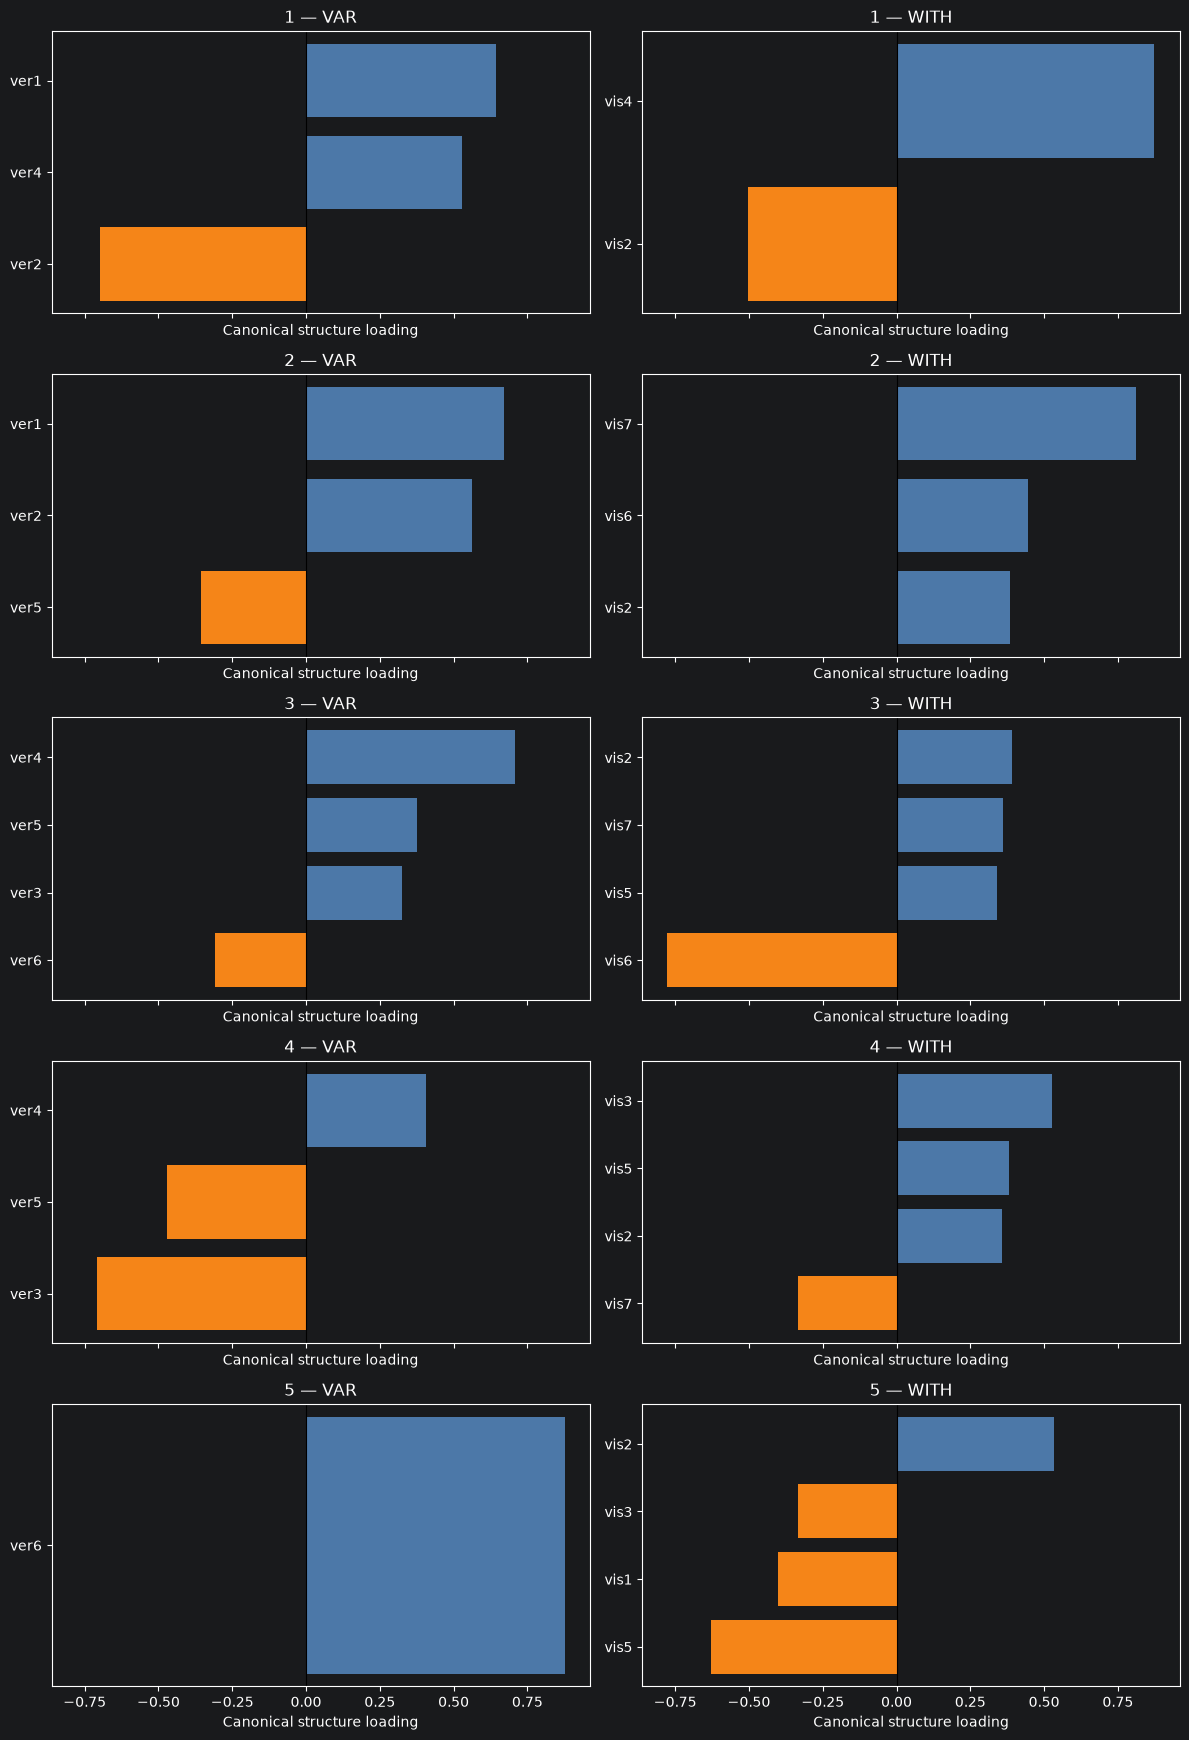

In [28]:
import matplotlib.pyplot as plt

required_columns = [
    "canonical_dimension",
    "modality",
    "variable",
    "loading",
]

missing_columns = [
    column for column in required_columns
    if column not in cca_dimension_loadings_df.columns
]

if missing_columns:
    raise ValueError(
        "cca_dimension_loadings_df is missing required columns: "
        + ", ".join(missing_columns)
    )

dimensions = sorted(
    cca_dimension_loadings_df["canonical_dimension"].unique(),
    key=lambda value: int(str(value).replace("canonical_dimension_", "")),
)

if not dimensions:
    raise ValueError("No canonical dimensions found in cca_dimension_loadings_df.")

fig, axes = plt.subplots(
    nrows=len(dimensions),
    ncols=2,
    figsize=(12, 3.5 * len(dimensions)),
    sharex=True,
)

if len(dimensions) == 1:
    axes = [axes]

for row_idx, dimension in enumerate(dimensions):
    for col_idx, modality in enumerate(["VAR", "WITH"]):
        ax = axes[row_idx][col_idx]

        subset = cca_dimension_loadings_df[
            cca_dimension_loadings_df["canonical_dimension"].eq(dimension)
            & cca_dimension_loadings_df["modality"].eq(modality)
            ].copy()

        subset = subset.sort_values("loading")

        if subset.empty:
            ax.text(
                0.5,
                0.5,
                "No loadings",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.axvline(0, color="black", linewidth=0.8)
            ax.set_title(f"{dimension} — {modality}")
            ax.set_xlabel("Canonical structure loading")
            ax.set_ylabel("")
            continue

        colors = [
            "#4C78A8" if value >= 0 else "#F58518"
            for value in subset["loading"]
        ]

        ax.barh(subset["variable"], subset["loading"], color=colors)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(f"{dimension} — {modality}")
        ax.set_xlabel("Canonical structure loading")
        ax.set_ylabel("")

plt.tight_layout()
plt.show()

##### Save paired VAR/WITH loading charts for each canonical dimension

In [29]:
from pathlib import Path

import matplotlib.pyplot as plt

output_dir = Path("../cl_st1_ph2_tatiana/corpus/figures/cca_dimension_loadings")
output_dir.mkdir(parents=True, exist_ok=True)

required_columns = [
    "canonical_dimension",
    "modality",
    "variable",
    "loading",
]

missing_columns = [
    column for column in required_columns
    if column not in cca_dimension_loadings_df.columns
]

if missing_columns:
    raise ValueError(
        "cca_dimension_loadings_df is missing required columns: "
        + ", ".join(missing_columns)
    )


def canonical_dimension_sort_key(value):
    return int(str(value).replace("canonical_dimension_", ""))


dimensions = sorted(
    cca_dimension_loadings_df["canonical_dimension"].unique(),
    key=canonical_dimension_sort_key,
)

saved_figure_paths = []

for dimension in dimensions:
    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(12, 4),
        sharex=True,
    )

    for ax, modality in zip(axes, ["VAR", "WITH"]):
        subset = cca_dimension_loadings_df[
            cca_dimension_loadings_df["canonical_dimension"].eq(dimension)
            & cca_dimension_loadings_df["modality"].eq(modality)
            ].copy()

        subset = subset.sort_values("loading")

        colors = [
            "#4C78A8" if value >= 0 else "#F58518"
            for value in subset["loading"]
        ]

        ax.barh(subset["variable"], subset["loading"], color=colors)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(f"{dimension} — {modality}")
        ax.set_xlabel("Canonical structure loading")
        ax.set_ylabel("")

    dimension_number = canonical_dimension_sort_key(dimension)

    fig.suptitle(f"Canonical dimension {dimension_number}", fontsize=14)
    fig.tight_layout()

    output_path = output_dir / f"canonical_dimension_{dimension_number}_loadings.png"
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    saved_figure_paths.append(output_path)

saved_figure_paths

[PosixPath('../cl_st1_ph2_tatiana/corpus/figures/cca_dimension_loadings/canonical_dimension_1_loadings.png'),
 PosixPath('../cl_st1_ph2_tatiana/corpus/figures/cca_dimension_loadings/canonical_dimension_2_loadings.png'),
 PosixPath('../cl_st1_ph2_tatiana/corpus/figures/cca_dimension_loadings/canonical_dimension_3_loadings.png'),
 PosixPath('../cl_st1_ph2_tatiana/corpus/figures/cca_dimension_loadings/canonical_dimension_4_loadings.png'),
 PosixPath('../cl_st1_ph2_tatiana/corpus/figures/cca_dimension_loadings/canonical_dimension_5_loadings.png')]

These results are **interpretable** because they are based on **canonical structure loadings**. They show which original verbal dimensions (`ver<n>`) and visual dimensions (`vis<n>`) correlate most strongly with each canonical variate.

A good way to read each canonical dimension is:

> A CCA dimension links a pattern of verbal dimensions with a pattern of visual dimensions. Variables with the same sign are aligned on the same pole of the dimension; variables with opposite signs define the opposing pole.

Because signs in CCA are arbitrary, you can flip all signs within a dimension without changing the meaning. What matters is the **relative opposition** among variables.